https://www.kaggle.com/code/venkatkrishnan/iris-data-tensorflow-neural-network

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Tensorflow libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential


In [ ]:
iris_data = pd.read_csv('/content/drive/MyDrive/ML dataset/iris.csv')
iris_data.head()

,sepal.length,sepal.width,petal.length,petal.width,variety
0,5.1,3.5,1.4,0.2,Setosa
1,4.9,3.0,1.4,0.2,Setosa
2,4.7,3.2,1.3,0.2,Setosa
3,4.6,3.1,1.5,0.2,Setosa
4,5.0,3.6,1.4,0.2,Setosa


In [ ]:
X = iris_data.loc[:, iris_data.columns != 'variety']
y = iris_data.loc[:, ['variety']]

In [ ]:
from sklearn.preprocessing import LabelEncoder
y_enc = LabelEncoder().fit_transform(y) # เรียนรู้ว่ามี label อะไรบ้าง และแปลง label ที่เป็นข้อความให้เป็น integer เช่น "setosa" → 0, "versicolor" → 1, "virginica" → 2
y_label = tf.keras.utils.to_categorical(y_enc)  # แปลงเลขคลาส (0, 1, 2) → one-hot encoded vector

# รูปแบบนี้จำเป็น ถ้าจะใช้ loss='categorical_crossentropy'

/usr/local/lib/python3.11/dist-packages/sklearn/preprocessing/_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y_label, test_size=0.2)

In [ ]:
print(f"Train shape : {X_train.shape}, Y Train : {y_train.shape}")
print(X_train.shape[1:])

Train shape : (120, 4), Y Train : (120, 3)
(4,)


In [ ]:
# นิยามฟังก์ชันชื่อ get_model ที่จะคืนค่า model
# ใช้ Sequential() สร้างโมเดลแบบ stacked layers
# เป็น Fully Connected Layers (Dense) มี neuron จำนวน 1000, 500, 300 ตามลำดับ
# ใช้ activation function แบบ ReLU (เหมาะกับ hidden layers)
# ใช้ Dropout เพื่อลด overfitting โดยสุ่มปิดการทำงานของ neuron บางส่วนในระหว่างการ train (20% ของ neuron ถูกปิดในแต่ละรอบ)
# output layer มี 3 neuron (ตามจำนวน 3 class) ใช้ softmax activation เพื่อให้ได้ probability distribution (ค่า output รวมกัน = 1)
def get_model():
    model = Sequential([
        keras.layers.Input(shape=X_train.shape[1:]),
        keras.layers.Dense(100, activation='relu'),
        keras.layers.Dense(50, activation='relu',),
        keras.layers.Dense(30, activation='relu'),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(3, activation='softmax')
    ])

    return model

In [ ]:
model = get_model()

# Compile the model
model.compile(optimizer='adam', loss=keras.losses.CategoricalCrossentropy(),
             metrics=['accuracy'])

In [ ]:
history = model.fit(X_train, y_train, epochs=30, validation_data=(X_test, y_test), verbose=1) # ถ้าไม่ได้ระบุ batch_size ไว้ใน model.fit() → ค่า default ของ Keras คือ batch_size=32

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.3512 - loss: 1.4100 - val_accuracy: 0.3333 - val_loss: 1.1740
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.3094 - loss: 1.2412 - val_accuracy: 0.3333 - val_loss: 1.0603
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3854 - loss: 1.0616 - val_accuracy: 0.3000 - val_loss: 1.0110
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4840 - loss: 0.9963 - val_accuracy: 0.6667 - val_loss: 0.9592
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5935 - loss: 0.9634 - val_accuracy: 0.6667 - val_loss: 0.9064
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6410 - loss: 0.9103 - val_accuracy: 0.6667 - val_loss: 0.8703
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.6585 - loss: 0.8818 - val_accuracy: 0.6667 - val_loss: 0.8249
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6748 - loss: 0.8461 - val_accuracy: 0.6667 - val_loss: 0.7790

In [ ]:
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9667 - loss: 0.1968


[0.19684536755084991, 0.9666666388511658]

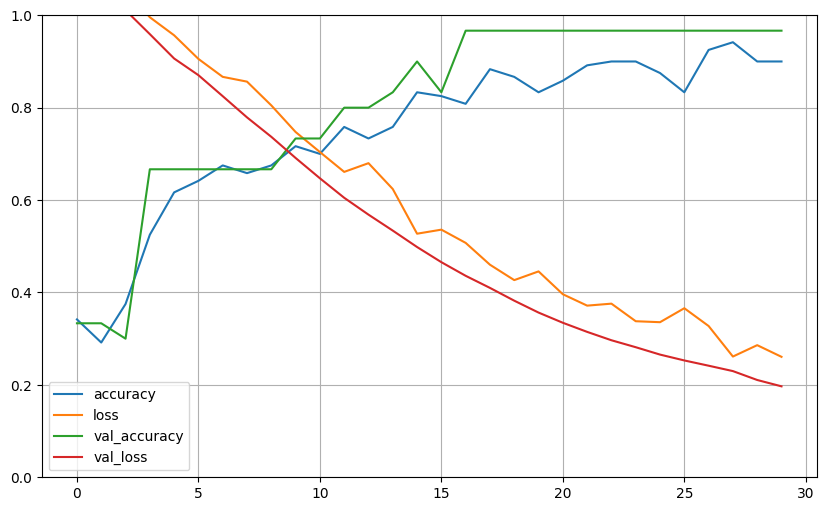

In [ ]:
pd.DataFrame(history.history).plot(figsize=(10,6))
plt.grid(True)
plt.gca().set_ylim(0, 1)
plt.show()

In [ ]:
new_data, y_actual = X_test[:3], y_test[:3]

y_proba = model.predict(new_data)

print(f"Actual data : {y_actual}")

for pred in y_proba:
    print(np.argmax(pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
Actual data : [[0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]]
2
1
0
